# Week 1: Auditing algorithmic fairness with ACSIncome dataset

**Learning goals**

1. Separate a target label, a prediction, and a decision.
2. Validate performance and group fairness.
3. Connect independence, separation, sufficiency, and calibration to their assumptions.

**Project 1 (Week 1)**

1. Guided - Auditing algorithmic fairness with ACSIncome dataset
2. Transfer your learning and perform an audit on the Portuguese banking marketing campaign dataset


### Task 1: The task predicts whether annual income exceeds USD 50,000 using 2018 ACS data. `SEX` is the binary coding available in this survey extract. It is not a complete measurement of gender identity.

In [ ]:
# pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn
from fairlearn.datasets import fetch_bank_marketing

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

## 1. Load and document the data

Before modelling, answer:

- What population is represented?
- What is the prediction target and who constructed it?
- Which variables are measurements, proxies, or administratively defined categories?
- Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html

In [4]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P
0,47.0,1.0,22.0,1.0,5740.0,6.0,1.0,40.0,2.0,1.0
1,44.0,1.0,19.0,1.0,440.0,6.0,0.0,45.0,1.0,1.0
2,41.0,4.0,16.0,1.0,4220.0,12.0,0.0,42.0,1.0,1.0
3,58.0,1.0,18.0,5.0,3605.0,6.0,0.0,40.0,1.0,2.0
4,36.0,1.0,19.0,1.0,1006.0,361.0,5.0,40.0,1.0,1.0


PINCP,income<=50k,income>50k
SEX,,
Female,0.650932,0.349068
Male,0.534432,0.465568


Rows: 50000 Features: 10


- **What population is represented?**

Ding et al. provide data from 2014-2018 for all 50 states and Puerto Rico. Note that Puerto Rico is the only US territory included in this dataset. We uploaded the 2018 data to OpenML. The dataset contains 1,664,500 rows. Each row describes a person and contains 10 features.

- **What is the prediction target and who constructed it?**

PINCP = Total annual income per person, denoted as an integer ranging from 104 to 1,423,000.  

- **Which variables are measurements, proxies, or administratively defined categories?**

Measurement: Age, sex,  SCHL = Educational attainment, POBP = Place of birth. 

in between?? Marital status

Administrative: COW = Class of worker, RAC1P = Race code, OCCP = Occupation, RELP = Relationship to householder

Proxy: WKHP = Usual hours worked per week 

- **Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html**

### Label notation used throughout the course

| Symbol | Meaning | Use |
|---|---|---|
| $Y^{ref}$ | Best available reference outcome | Final validation and test audit |
| $Y^{obs}$ | Label available to us; in real-life | Training and realistic validation |
| $S=P(\hat Y=1)$ | Model score | Ranking and calibration |
| $\hat Y$ | Thresholded or postprocessed decision | Decision metrics |

In Week 1, $Y^{obs}=Y^{ref}$. Later weeks deliberately separate them. “Reference” is more accurate than “ground truth”: real labels can still be incomplete or contestable.

In [5]:
idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + sex_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(sex_group, z) for z in (train_idx, val_idx, test_idx)]
R_train, R_val, R_test = [take(race_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_fraction": [(A_train=="Female").mean(), (A_val=="Female").mean(), (A_test=="Female").mean()],
}))

,split,n,positive_rate,female_fraction
0,train,30000,0.4106,0.472
1,validation,10000,0.4105,0.472
2,test,10000,0.4106,0.472


Postivie rate is just how many are over 50.000 in income.


## 2. Fit a transparent baseline

We retain `SEX` and `RAC1P` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [6]:
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Performance | Accuracy, balanced accuracy, AUROC, log loss | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

Read the documentation of fairlearn.metrics and sklearn.metrics to identify the performance measures needed to assess Independence, Separation (Equalized Odds), Equal Opportunity, and Sufficiency. Add them to the analysis of the classifier as illustrated above, and create fairness diagnostics metrics that consider a ratio of metrics for the groups at hand, in a way that is consistent with each of the fairness criteria.

If you apply the standard practice of "more than 20% discrepancy is a problem" -- which combinations of datasets and fairness criteria lead to a conclusion of problematic bias?

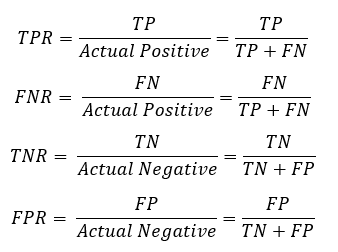

In [7]:
# TODO # instead of using fairlearn/sklearn metrics, code your own using numpy

def false_positive_rate_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement false_positive_rate_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp          # everyone who is actually negative
    return fp / denominator if denominator > 0 else np.nan


def true_negative_rate_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement true_negative_rate_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp          # everyone who is actually positive
    return tn / denominator if denominator > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    #raise NotImplementedError("TODO: implement negative_predictive_value_metric")
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fn # everyone the model predicted negative
    return tn / denominator  if denominator else np.nan

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

#raise NotImplementedError("TODO: calculate the fairness summary metrics")    
#       
fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(y_true=y_val, y_pred=val_pred, sensitive_features=A_val),
    "demographic_parity_ratio": demographic_parity_ratio(y_true=y_val, y_pred=val_pred, sensitive_features=A_val),
    "equalized_odds_difference": equalized_odds_difference(y_true=y_val, y_pred=val_pred, sensitive_features=A_val),
    "equalized_odds_ratio": equalized_odds_ratio(y_true=y_val, y_pred=val_pred, sensitive_features=A_val),
})
display(fairness_summary)


Overall threshold metrics


n                    10000.000000
accuracy                 0.818400
balanced_accuracy        0.812315
selection_rate           0.410100
TPR_recall               0.778319
FPR                      0.153690
PPV_precision            0.779078
NPV                      0.845737
TNR                      0.846310
dtype: float64

By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.817797,0.796114,0.338771,0.724347,0.132118,0.746091,0.854534,0.867882
Male,5280.0,0.818939,0.818652,0.473864,0.814483,0.177179,0.800160,0.835853,0.822821


Maximum minus minimum


n                    560.000000
accuracy               0.001143
balanced_accuracy      0.022538
selection_rate         0.135092
TPR_recall             0.090136
FPR                    0.045061
PPV_precision          0.054069
NPV                    0.018681
TNR                    0.045061
dtype: float64

Minimum divided by maximum


n                    0.893939
accuracy             0.998605
balanced_accuracy    0.972470
selection_rate       0.714913
TPR_recall           0.889333
FPR                  0.745677
PPV_precision        0.932428
NPV                  0.978139
TNR                  0.948079
dtype: float64

demographic_parity_difference    0.135092
demographic_parity_ratio         0.714913
equalized_odds_difference        0.090136
equalized_odds_ratio             0.745677
dtype: float64

In [8]:
#raise NotImplementedError("TODO: calculate the overall probability metrics")
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score)
})
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m])
    })
display(pd.DataFrame(prob_rows).set_index("group"))

ROC_AUC     0.896281
log_loss    0.401220
dtype: float64

,n,ROC_AUC,log_loss
group,,,
Female,4720,0.893618,0.391304
Male,5280,0.894879,0.410085


### Interpretation checkpoint

Think:

1. Which group has the higher selection rate, and by how much?
Male has the higher with 0.47 which is 0.14 higher than for women. Which means the model predicts a higher part of the males as true, meaning they are predicted more to earn more than 50.000

2. Which group has the higher FPR and which has the higher TPR?
FPR males have higher 0.177 and TPR males also have higher. The model will in larger proportions predict males to earn more.

3. Does the direction of the PPV gap match the direction of the selection-rate gap?
PPV for males are 0.8 and for females is 0.74 - so its given that the if the model says that if a male earns over 50.000 it the probability that they actually also to is 80%. It has a higher prob of guessing correctly for a male than for a female. 


4. What can you **not** conclude from these numbers alone?
If we apply the "more that 20% discrepancy is a problem" - The conclusion would not be that the model is biased? but some of the numbers suggest it might be biased towards men. But we CANNOT conlcude exactly how much they are making and how the proportions/volumes 

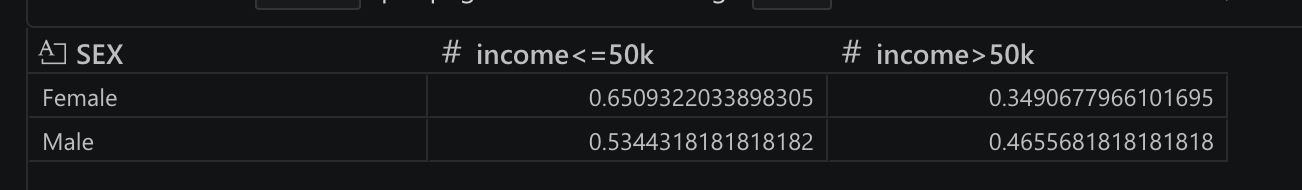

**Optional: Write down your interpretation**
1. Selection rate comparison: ...
2. FPR/TPR comparison: ...
3. PPV gap vs. selection-rate gap: ...
4. What you cannot conclude: ...

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.10,0.6809,0.109200,0.008195,0.090321
1,0.15,0.7253,0.112930,0.009529,0.081877
2,0.20,0.7589,0.116452,0.021398,0.069768
3,0.25,0.7805,0.123754,0.030613,0.070069
4,0.30,0.7937,0.130807,0.044680,0.069698
5,0.35,0.8049,0.131638,0.054283,0.062464
6,0.40,0.8119,0.134409,0.065690,0.058977
7,0.45,0.8177,0.134877,0.073071,0.054326
8,0.50,0.8184,0.135092,0.090136,0.045061
9,0.55,0.8176,0.135317,0.101524,0.040106


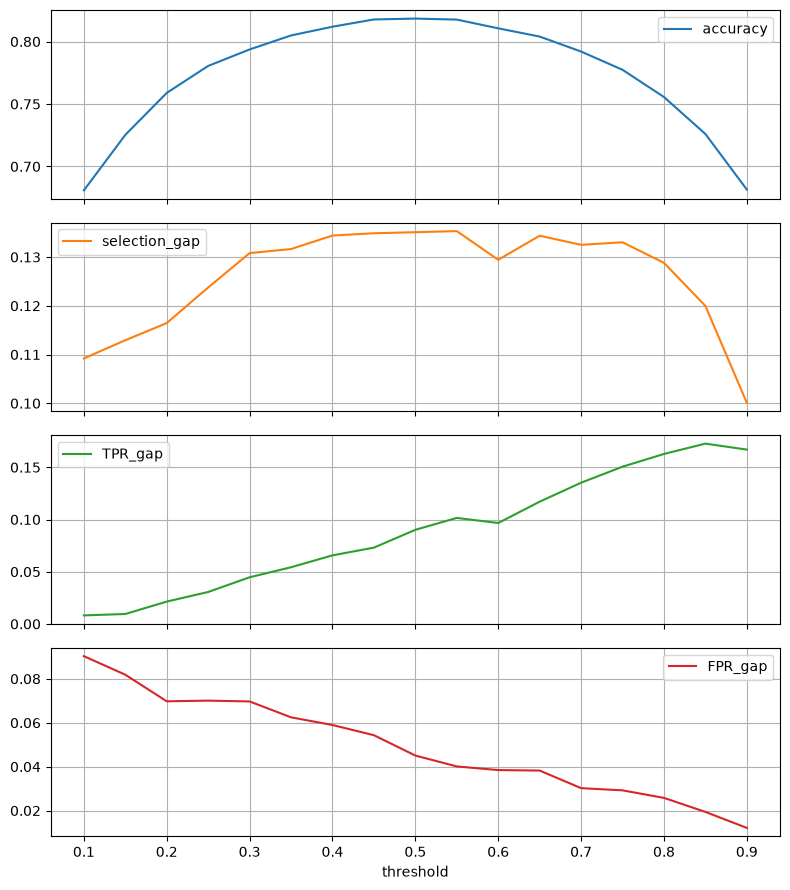

In [9]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

## 5. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [10]:
# TODO 1: fit a second model after removing SEX and RAC1P from predictive features.
# Retain A_val and R_val for auditing.
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["SEX", "RAC1P"]]

model_without_a =  make_model(X_train[FEATURES_WITHOUT_A])
model_without_a.fit(X_train[FEATURES_WITHOUT_A], y_train)
score_without_a = model_without_a.predict_proba(X_val[FEATURES])[:,1]
pred_without_a = (score_without_a >= .50).astype(int)

mf_without_a = MetricFrame(metrics=metrics, y_true=y_val, y_pred=pred_without_a, sensitive_features=A_val)

print("Overall threshold metrics")
print("By group")
display(mf_without_a.by_group)

Overall threshold metrics
By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
SEX,,,,,,,,,
Female,4720.0,0.819068,0.806529,0.365890,0.765027,0.151969,0.729589,0.870698,0.848031
Male,5280.0,0.819886,0.817990,0.450568,0.790480,0.154500,0.816730,0.822475,0.845500


In [11]:
# Optional

# TODO 2: create an intersectional sensitive feature such as SEX x RACE.
# Require a minimum group size before interpreting a result.
intersection = A_val.astype(str) + " | " + R_val.astype(str)
display(intersection.value_counts().head(15))

Male | White                   3337
Female | White                 2802
Female | Asian                  894
Male | Asian                    822
Male | Other race               655
Female | Other race             541
Female | Black                  239
Male | Black                    200
Male | Two or more races        198
Female | Two or more races      192
Male | American Indian           36
Female | American Indian         23
Female | Pacific Islander        20
Male | Pacific Islander          19
Male | AIAN specified/other      13
Name: count, dtype: int64

## Task 2: Perform fairness auditing on a marketing campaign dataset

Repeat the analysis on a new dataset - https://fairlearn.org/v0.13/api_reference/generated/fairlearn.datasets.fetch_bank_marketing.html

What do you learn about bias diagnostic? How are these metrics different?

In [32]:
bank_marketing = fetch_bank_marketing(as_frame=True)
df = bank_marketing.frame
df = df.rename(columns={"V1":"age","V2":"job","V3":"marital","V4":"education","V5":"default","V6":"balance","V7":"housing","V8":"loan","V9":"contact","V10":"day_of_week","V11":"month","V12":"duration","V13":"campaign","V14":"pdays","V15":"previous","V16":"poutcome","Class":"target"})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [24]:
df.describe()

,V1,V6,V10,V12,V13,V14,V15
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])

## 📝 Project 1 Submission Guidelines

**Format:** Project 1 will be submitted as an **A0 Poster**. 

**Week 1 Contribution:**
The findings and discussions generated from this Week 1 notebook should form the foundation of your project and cover approximately **1/3 of your final poster**. 

When preparing your poster, ensure that this section includes:
* Clearly outline the context, goals, and intended real-world impact of the model. 
* Explain what the different fairness metrics represent in the context of this specific use case (e.g., what does a disparity in False Positive Rate mean for the individuals actually affected?).
* Provide a short analysis of the bias present in the ACSIncome dataset and Bank Marketing dataset - from your exploratory data analysis and the fairness metric evaluations conducted in this notebook.
